# Metadata Tags Statistical Analysis

This notebook provides a comprehensive analysis of tags in the metadata_merged.csv file.

**Dataset Overview:**
- Total records: 521,735
- Records with tags: 214,603 (41.1%)
- Unique tags: 597
- Tag format: Comma-separated strings

## 1. Data Loading and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load data
data_path = 'data/metadata_merged.csv'
df = pd.read_csv(data_path, low_memory=False)

print(f"Total records: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Total records: 521,735
Columns: ['Id', 'Title', 'Slug', 'Tags', 'CreatorUserId', 'OwnerUserId', 'OwnerOrganizationId', 'CurrentDatasetVersionId', 'CurrentDatasourceVersionId', 'ForumId', 'Type', 'CreationDate', 'LastActivityDate', 'TotalViews', 'TotalDownloads', 'TotalVotes', 'TotalKernels', 'Medal', 'MedalAwardDate', 'Subtitle', 'Description', 'CreationDate_dt', 'LastActivityDate_dt', 'age_days', 'days_since_last_activity', 'active_30d', 'has_tags', 'TotalViews_log1p', 'TotalDownloads_log1p', 'TotalVotes_log1p', 'TotalKernels_log1p']

First few rows:


,Id,Title,Slug,Tags,CreatorUserId,OwnerUserId,OwnerOrganizationId,CurrentDatasetVersionId,CurrentDatasourceVersionId,ForumId,Type,CreationDate,LastActivityDate,TotalViews,TotalDownloads,TotalVotes,TotalKernels,Medal,MedalAwardDate,Subtitle,Description,CreationDate_dt,LastActivityDate_dt,age_days,days_since_last_activity,active_30d,has_tags,TotalViews_log1p,TotalDownloads_log1p,TotalVotes_log1p,TotalKernels_log1p
0,6,2013 American Community Survey,2013-american-community-survey,"computer science, demographics, social science",1,NaN,12.0,2158.0,2158.0,762,Dataset,07/18/2015 00:51:12,02/05/2018,79466,6800,103,624,3.0,11/06/2019,Find insights in the 2013 American Community S...,The [American Community Survey](http://www.cen...,2015-07-18 00:51:12,2018-02-05 00:00:00,3762,2830,False,True,11.283097,8.824825,4.644391,6.437752
1,7,May 2015 Reddit Comments,reddit-comments-may-2015,"internet, linguistics, online communities",491632,NaN,4.0,469900.0,485806.0,766,Dataset,08/04/2015 23:59:00,02/06/2018,123284,11509,298,595,2.0,10/01/2024,Get personal with a dataset of comments from M...,Recently Reddit released [an enormous dataset]...,2015-08-04 23:59:00,2018-02-06 00:00:00,3745,2829,False,True,11.722254,9.350972,5.700444,6.390241
2,8,Ocean Ship Logbooks (1750-1850),climate-data-from-ocean-ships,"atmospheric science, environment",495305,NaN,6.0,7142.0,7142.0,774,Dataset,08/18/2015 21:53:00,01/31/2018,52158,4650,117,77,3.0,07/05/2021,Explore changing climatology with data from ea...,"In the mid-eighteenth to nineteenth centuries,...",2015-08-18 21:53:00,2018-01-31 00:00:00,3731,2835,False,True,10.862052,8.444838,4.770685,4.356709
3,9,Meta Kaggle,meta-kaggle,"computer science, tabular",1,NaN,4.0,12785440.0,13410983.0,794,Dataset,09/08/2015 19:01:00,02/05/2018,336112,31466,1082,1261,1.0,11/06/2019,"Kaggle's public data on competitions, users, s...",#Meta Kaggle \n##Explore our public data on c...,2015-09-08 19:01:00,2018-02-05 00:00:00,3710,2830,False,True,12.725203,10.356695,6.987490,7.140453
4,10,Hillary Clinton's Emails,hillary-clinton-emails,"government, news, politics",993,NaN,4.0,793490.0,815288.0,798,Dataset,09/11/2015 01:56:00,02/06/2018,212405,20079,304,342,2.0,06/19/2021,Uncover the political landscape in Hillary Cli...,"Throughout 2015, Hillary Clinton has been embr...",2015-09-11 01:56:00,2018-02-06 00:00:00,3707,2829,False,True,12.266255,9.907480,5.720312,5.837730


In [3]:
# Parse tags - split comma-separated strings into lists
def parse_tags(tag_string):
    """Parse comma-separated tag string into list of tags"""
    if pd.isna(tag_string):
        return []
    return [tag.strip() for tag in str(tag_string).split(',')]

df['tags_list'] = df['Tags'].apply(parse_tags)
df['num_tags'] = df['tags_list'].apply(len)

# Filter documents with tags
df_with_tags = df[df['num_tags'] > 0].copy()

print(f"Documents with tags: {len(df_with_tags):,} ({len(df_with_tags)/len(df)*100:.1f}%)")
print(f"Documents without tags: {len(df) - len(df_with_tags):,} ({(len(df) - len(df_with_tags))/len(df)*100:.1f}%)")

Documents with tags: 214,603 (41.1%)
Documents without tags: 307,132 (58.9%)


## 2. Basic Statistics

In [4]:
# Collect all tags
all_tags = []
for tags in df_with_tags['tags_list']:
    all_tags.extend(tags)

# Count unique tags
unique_tags = set(all_tags)
tag_counter = Counter(all_tags)

print("=" * 60)
print("BASIC TAG STATISTICS")
print("=" * 60)
print(f"Total documents: {len(df):,}")
print(f"Documents with tags: {len(df_with_tags):,}")
print(f"Tag coverage: {len(df_with_tags)/len(df)*100:.2f}%")
print()
print(f"Unique tags: {len(unique_tags):,}")
print(f"Total tag occurrences: {len(all_tags):,}")
print(f"Average tags per document: {len(all_tags)/len(df_with_tags):.2f}")
print()
print(f"Min tags per document: {df_with_tags['num_tags'].min()}")
print(f"Max tags per document: {df_with_tags['num_tags'].max()}")
print(f"Median tags per document: {df_with_tags['num_tags'].median():.0f}")
print(f"Mean tags per document: {df_with_tags['num_tags'].mean():.2f}")
print("=" * 60)

BASIC TAG STATISTICS
Total documents: 521,735
Documents with tags: 214,603
Tag coverage: 41.13%

Unique tags: 597
Total tag occurrences: 446,064
Average tags per document: 2.08

Min tags per document: 1
Max tags per document: 11
Median tags per document: 1
Mean tags per document: 2.08


## 3. Tag Frequency Analysis

In [5]:
# Top 30 most common tags
top_30_tags = tag_counter.most_common(30)

print("Top 30 Most Common Tags:\n")
print(f"{'Rank':<6} {'Tag':<35} {'Count':<10} {'% of Docs'}")
print("-" * 65)
for i, (tag, count) in enumerate(top_30_tags, 1):
    percentage = count / len(df_with_tags) * 100
    print(f"{i:<6} {tag:<35} {count:<10,} {percentage:>6.1f}%")

Top 30 Most Common Tags:

Rank   Tag                                 Count      % of Docs
-----------------------------------------------------------------
1      pre-trained model                   30,498       14.2%
2      business                            27,014       12.6%
3      earth and nature                    17,261        8.0%
4      computer science                    12,007        5.6%
5      arts and entertainment              11,738        5.5%
6      tabular                             11,589        5.4%
7      education                           8,809         4.1%
8      data analytics                      8,283         3.9%
9      image                               8,064         3.8%
10     beginner                            8,030         3.7%
11     health                              7,581         3.5%
12     text                                7,424         3.5%
13     data visualization                  7,388         3.4%
14     movies and tv shows            

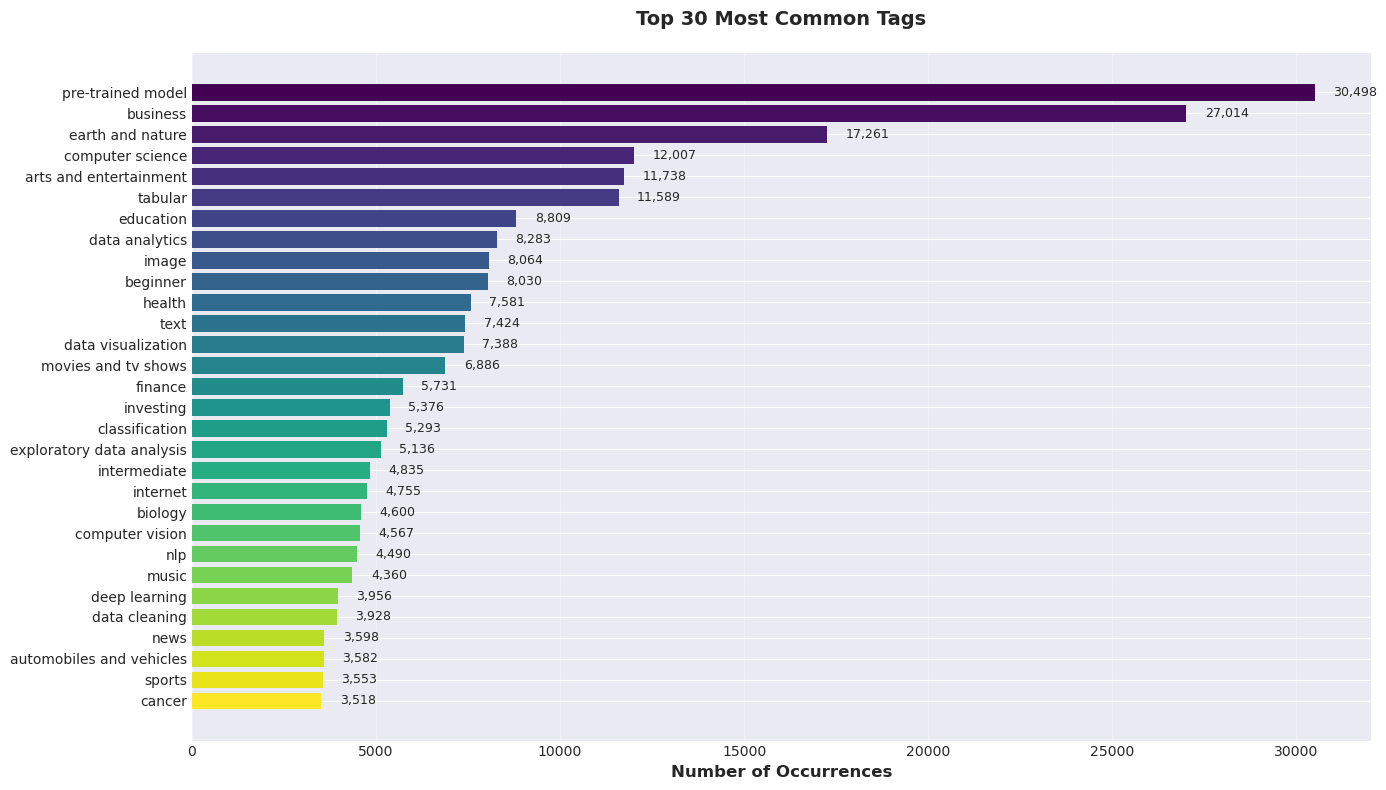

In [6]:
# Visualize top 30 tags
fig, ax = plt.subplots(figsize=(14, 8))
tags, counts = zip(*top_30_tags)
y_pos = np.arange(len(tags))

bars = ax.barh(y_pos, counts, color=plt.cm.viridis(np.linspace(0, 1, 30)))
ax.set_yticks(y_pos)
ax.set_yticklabels(tags)
ax.invert_yaxis()
ax.set_xlabel('Number of Occurrences', fontsize=12, fontweight='bold')
ax.set_title('Top 30 Most Common Tags', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

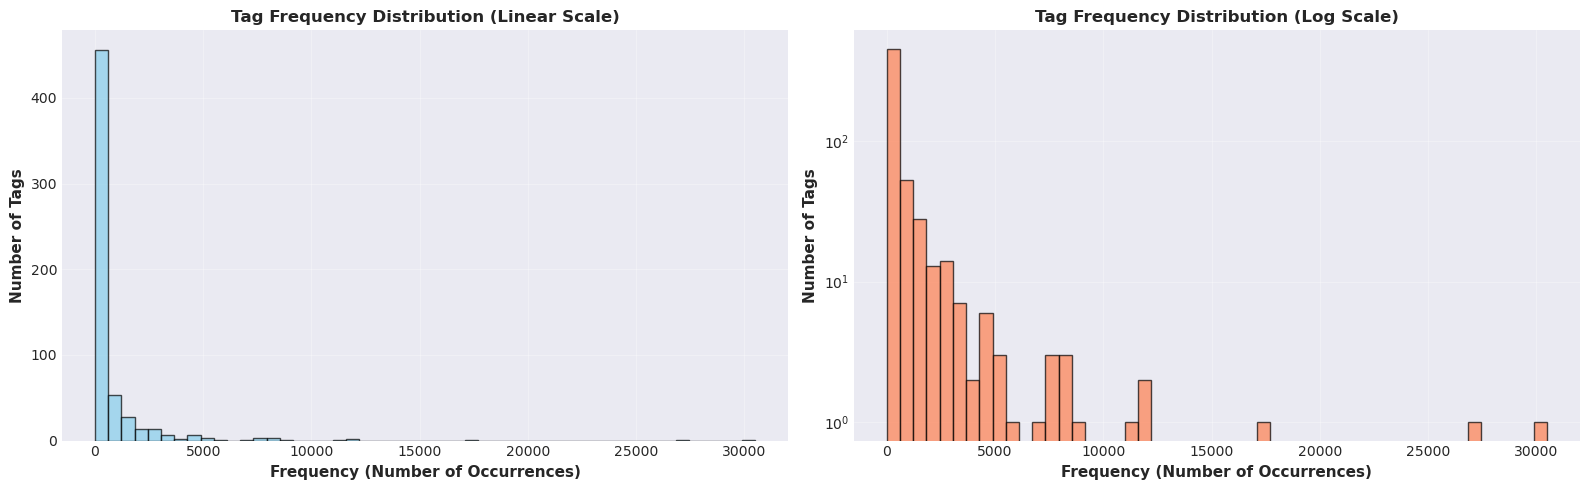


Frequency Statistics:
Min frequency: 1
Max frequency: 30498
Median frequency: 72
Mean frequency: 747.18


In [7]:
# Tag frequency distribution (histogram)
frequencies = list(tag_counter.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear scale
axes[0].hist(frequencies, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Frequency (Number of Occurrences)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Tags', fontsize=11, fontweight='bold')
axes[0].set_title('Tag Frequency Distribution (Linear Scale)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Log scale
axes[1].hist(frequencies, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Frequency (Number of Occurrences)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Tags', fontsize=11, fontweight='bold')
axes[1].set_title('Tag Frequency Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFrequency Statistics:")
print(f"Min frequency: {min(frequencies)}")
print(f"Max frequency: {max(frequencies)}")
print(f"Median frequency: {np.median(frequencies):.0f}")
print(f"Mean frequency: {np.mean(frequencies):.2f}")

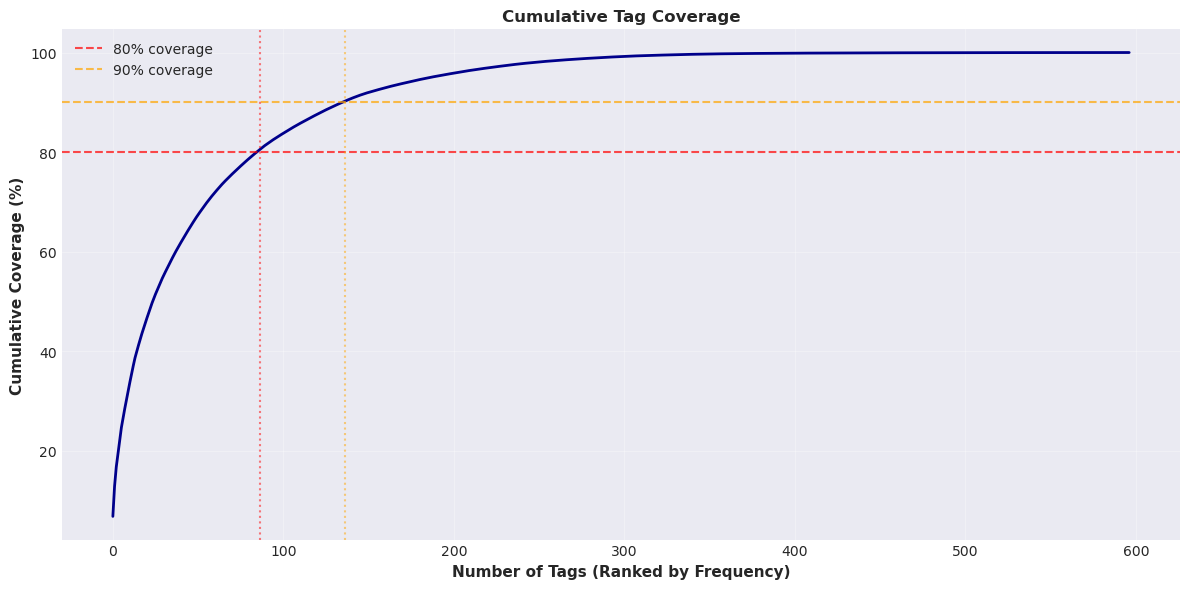


Top 86 tags cover 80% of all tag occurrences
Top 136 tags cover 90% of all tag occurrences


In [8]:
# Cumulative distribution
sorted_counts = sorted(frequencies, reverse=True)
cumulative_coverage = np.cumsum(sorted_counts) / sum(sorted_counts) * 100

plt.figure(figsize=(12, 6))
plt.plot(range(len(cumulative_coverage)), cumulative_coverage, linewidth=2, color='darkblue')
plt.axhline(y=80, color='red', linestyle='--', label='80% coverage', alpha=0.7)
plt.axhline(y=90, color='orange', linestyle='--', label='90% coverage', alpha=0.7)

# Find tags needed for 80% and 90% coverage
tags_80 = np.where(cumulative_coverage >= 80)[0][0] + 1
tags_90 = np.where(cumulative_coverage >= 90)[0][0] + 1

plt.axvline(x=tags_80, color='red', linestyle=':', alpha=0.5)
plt.axvline(x=tags_90, color='orange', linestyle=':', alpha=0.5)

plt.xlabel('Number of Tags (Ranked by Frequency)', fontsize=11, fontweight='bold')
plt.ylabel('Cumulative Coverage (%)', fontsize=11, fontweight='bold')
plt.title('Cumulative Tag Coverage', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTop {tags_80} tags cover 80% of all tag occurrences")
print(f"Top {tags_90} tags cover 90% of all tag occurrences")

In [9]:
# Rare tags analysis
rare_tags = [tag for tag, count in tag_counter.items() if count == 1]
low_freq_tags = [tag for tag, count in tag_counter.items() if count <= 5]

print(f"Tags appearing only once: {len(rare_tags)}")
print(f"Tags appearing 5 times or less: {len(low_freq_tags)}")
print(f"\nSample of rare tags (appearing once):")
print(rare_tags[:20])

Tags appearing only once: 67
Tags appearing 5 times or less: 171

Sample of rare tags (appearing once):
['mlp-mixer', 'reshape2', 'kashmiri', 'kyrgyz', 'ganda', 'inception v1', 'dzongkha', 'latin', 'multi-head attention', 'bigan', 'i3d', 'residual block', 'elmo', 'retinanet', 'javanese', 'packages', 'deeplab (mobilenetv2_coco_voc_trainval)', 'castilian', 'central khmer', 'scottish gaelic']


## 4. Tags Per Document Distribution

In [10]:
# Distribution of number of tags per document
tags_per_doc_dist = df_with_tags['num_tags'].value_counts().sort_index()

print("Distribution of Tags Per Document:\n")
print(f"{'# Tags':<10} {'Count':<12} {'Percentage'}")
print("-" * 40)
for num_tags, count in tags_per_doc_dist.items():
    percentage = count / len(df_with_tags) * 100
    print(f"{num_tags:<10} {count:<12,} {percentage:>6.1f}%")

Distribution of Tags Per Document:

# Tags     Count        Percentage
----------------------------------------
1          132,400        61.7%
2          23,205         10.8%
3          12,894          6.0%
4          12,764          5.9%
5          24,645         11.5%
6          6,940           3.2%
7          1,445           0.7%
8          267             0.1%
9          31              0.0%
10         11              0.0%
11         1               0.0%


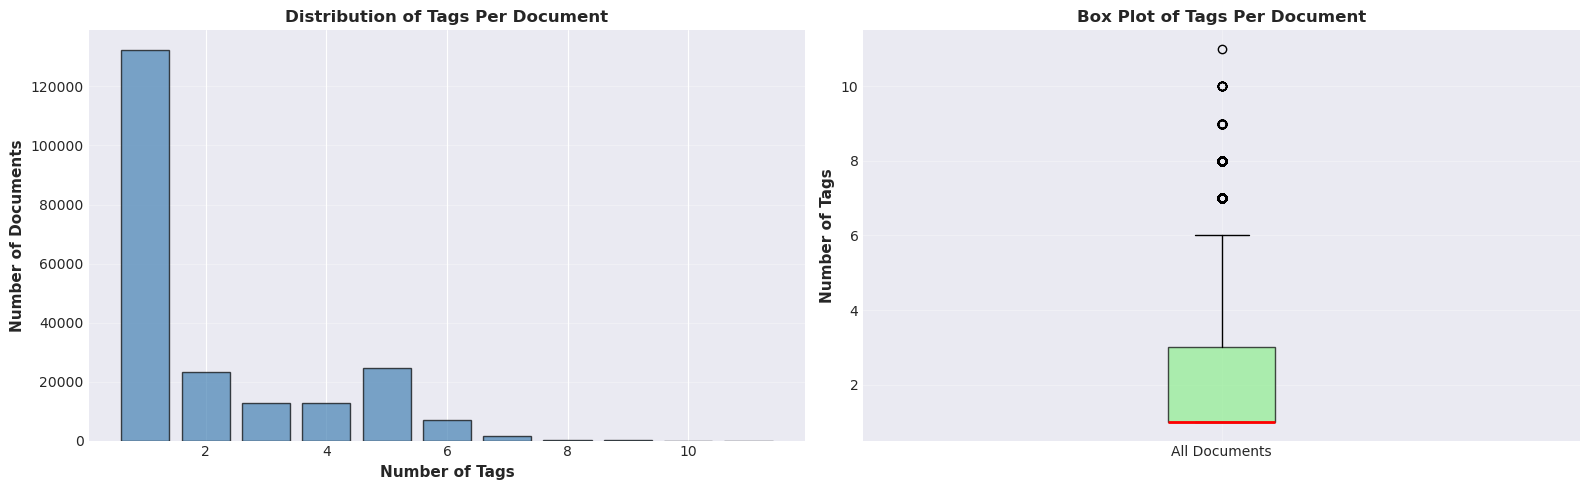


Statistics:
Q1 (25th percentile): 1
Median (50th percentile): 1
Q3 (75th percentile): 3
IQR: 2


In [11]:
# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
axes[0].bar(tags_per_doc_dist.index, tags_per_doc_dist.values, 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Tags', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Documents', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Tags Per Document', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot([df_with_tags['num_tags']], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Number of Tags', fontsize=11, fontweight='bold')
axes[1].set_title('Box Plot of Tags Per Document', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_xticklabels(['All Documents'])

plt.tight_layout()
plt.show()

# Statistics
print(f"\nStatistics:")
print(f"Q1 (25th percentile): {df_with_tags['num_tags'].quantile(0.25):.0f}")
print(f"Median (50th percentile): {df_with_tags['num_tags'].quantile(0.50):.0f}")
print(f"Q3 (75th percentile): {df_with_tags['num_tags'].quantile(0.75):.0f}")
print(f"IQR: {df_with_tags['num_tags'].quantile(0.75) - df_with_tags['num_tags'].quantile(0.25):.0f}")

## 5. Tag Co-occurrence Analysis

In [12]:
# Build co-occurrence matrix
cooccurrence = defaultdict(int)

for tags in df_with_tags['tags_list']:
    if len(tags) > 1:
        # Generate all pairs of tags
        for tag1, tag2 in combinations(sorted(tags), 2):
            cooccurrence[(tag1, tag2)] += 1

# Sort by frequency
top_cooccurrences = sorted(cooccurrence.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"Total unique tag pairs: {len(cooccurrence):,}")
print(f"Documents with multiple tags: {len([t for t in df_with_tags['tags_list'] if len(t) > 1]):,}")
print(f"\nTop 20 Co-occurring Tag Pairs:\n")
print(f"{'Rank':<6} {'Tag 1':<35} {'Tag 2':<35} {'Count'}")
print("-" * 90)
for i, ((tag1, tag2), count) in enumerate(top_cooccurrences, 1):
    print(f"{i:<6} {tag1:<35} {tag2:<35} {count:>5,}")

Total unique tag pairs: 31,711
Documents with multiple tags: 82,203

Top 20 Co-occurring Tag Pairs:

Rank   Tag 1                               Tag 2                               Count
------------------------------------------------------------------------------------------
1      data analytics                      data visualization                  3,403
2      computer vision                     image                               2,779
3      beginner                            tabular                             2,476
4      computer science                    programming                         2,419
5      data visualization                  exploratory data analysis           2,184
6      business                            investing                           2,144
7      finance                             investing                           2,017
8      data analytics                      data cleaning                       1,986
9      business                            

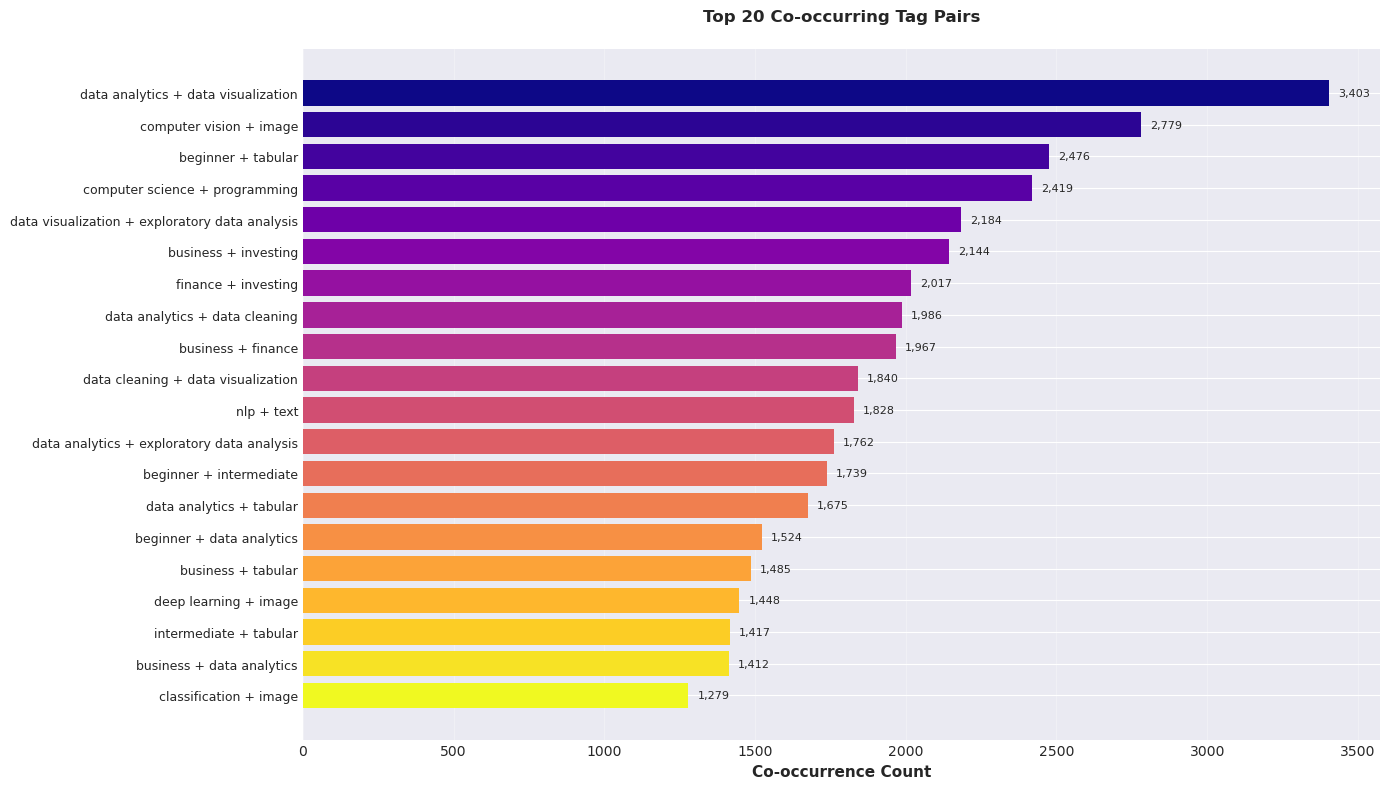

In [13]:
# Visualize top co-occurrences
fig, ax = plt.subplots(figsize=(14, 8))

pairs_labels = [f"{tag1} + {tag2}" for (tag1, tag2), _ in top_cooccurrences]
counts = [count for _, count in top_cooccurrences]
y_pos = np.arange(len(pairs_labels))

bars = ax.barh(y_pos, counts, color=plt.cm.plasma(np.linspace(0, 1, 20)))
ax.set_yticks(y_pos)
ax.set_yticklabels(pairs_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Co-occurrence Count', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Co-occurring Tag Pairs', fontsize=12, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 30, bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

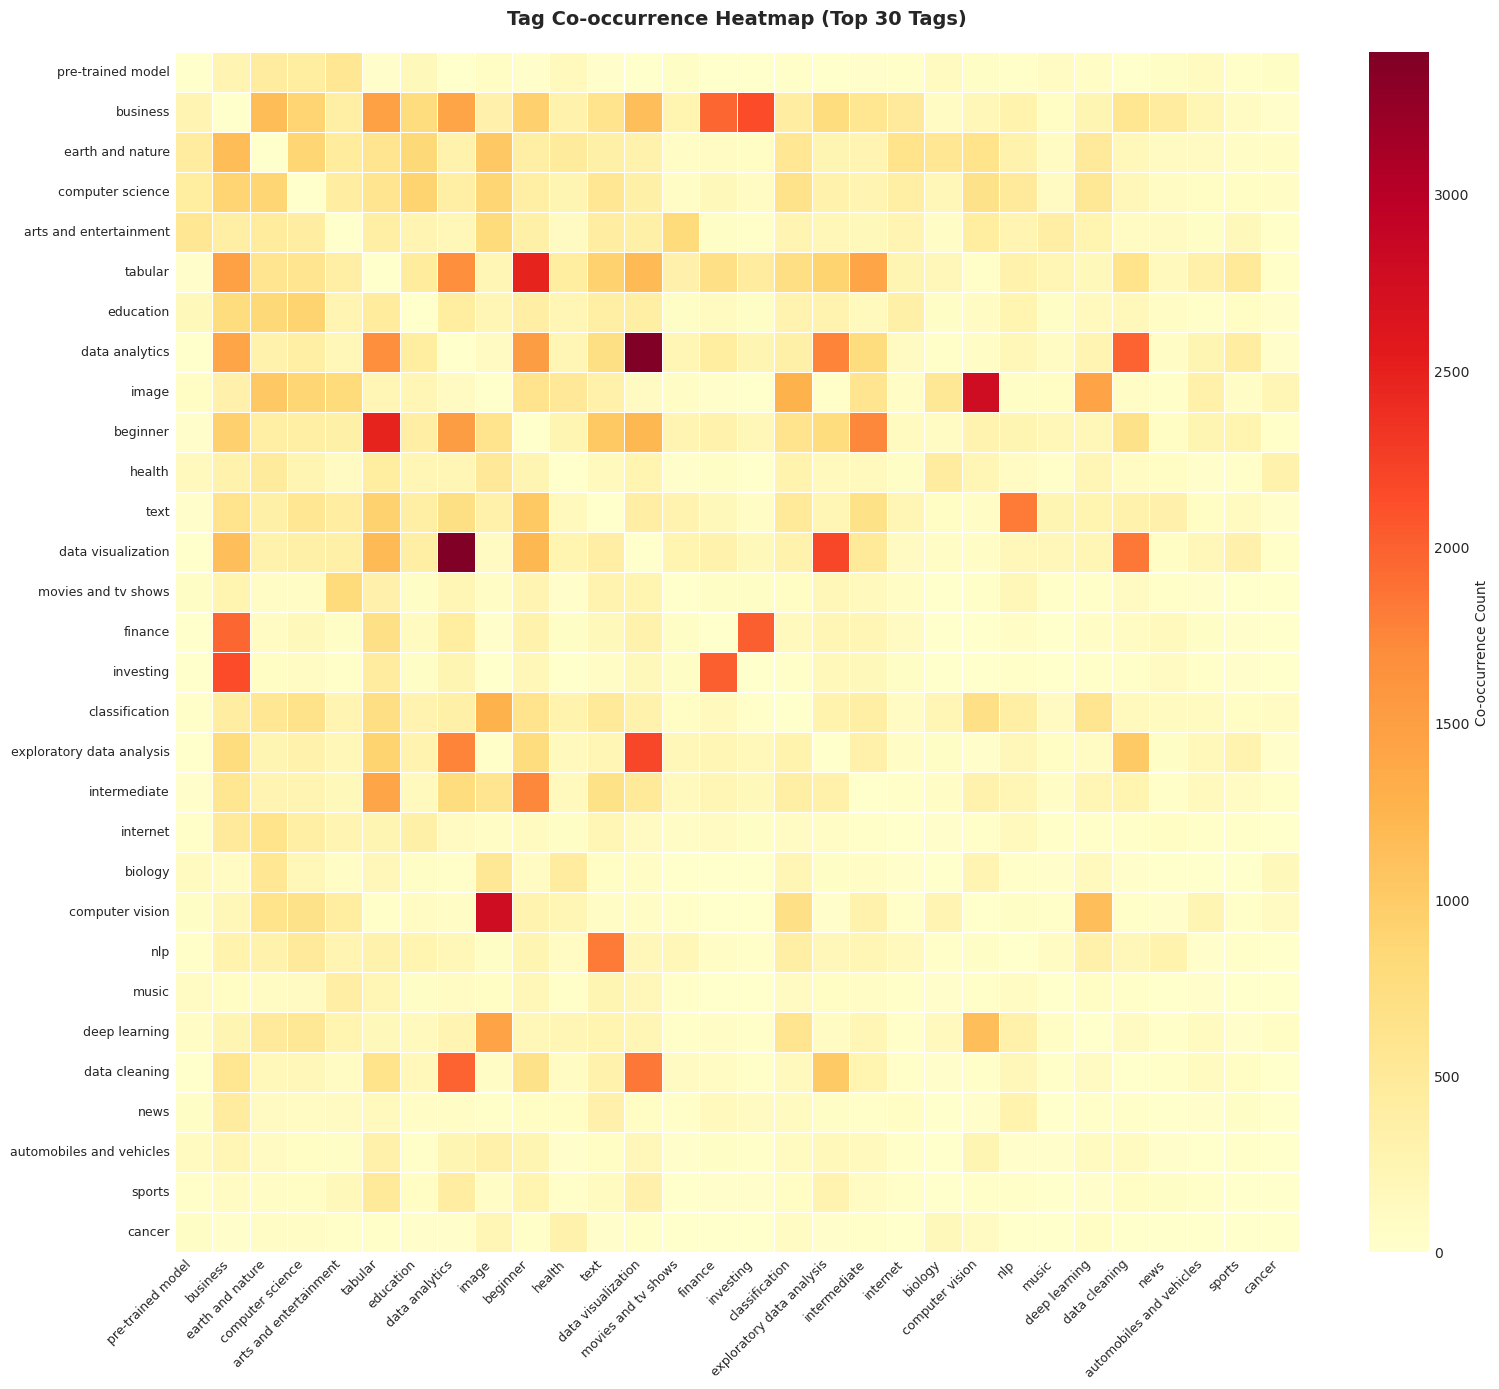

In [14]:
# Create co-occurrence matrix for top 30 tags
top_30_tag_names = [tag for tag, _ in top_30_tags]
cooc_matrix = pd.DataFrame(0, index=top_30_tag_names, columns=top_30_tag_names)

for (tag1, tag2), count in cooccurrence.items():
    if tag1 in top_30_tag_names and tag2 in top_30_tag_names:
        cooc_matrix.loc[tag1, tag2] = count
        cooc_matrix.loc[tag2, tag1] = count

# Heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cooc_matrix, annot=False, cmap='YlOrRd', linewidths=0.5, 
            cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Tag Co-occurrence Heatmap (Top 30 Tags)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Tag Semantic Categorization

In [15]:
# Categorize tags by type
tag_categories = {
    'Domain': ['business', 'finance', 'health', 'education', 'arts and entertainment', 
               'earth and nature', 'biology', 'cancer', 'news', 'sports', 'music'],
    'Skill Level': ['beginner', 'intermediate', 'advanced', 'expert'],
    'Data Type': ['tabular', 'image', 'text', 'time series', 'geospatial'],
    'Technology': ['computer vision', 'nlp', 'deep learning', 'machine learning', 
                   'pre-trained model', 'computer science', 'programming'],
    'Task': ['classification', 'regression', 'clustering', 'data cleaning', 
             'data visualization', 'exploratory data analysis', 'data analytics']
}

# Count tags in each category
category_counts = {}
for category, category_tags in tag_categories.items():
    total = sum(tag_counter.get(tag, 0) for tag in category_tags)
    category_counts[category] = total

print("Tag Distribution by Category:\n")
print(f"{'Category':<20} {'Count':<12} {'% of All Tags'}")
print("-" * 50)
for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = count / len(all_tags) * 100
    print(f"{category:<20} {count:<12,} {percentage:>6.1f}%")

Tag Distribution by Category:

Category             Count        % of All Tags
--------------------------------------------------
Domain               97,763         21.9%
Technology           58,535         13.1%
Task                 32,849          7.4%
Data Type            27,077          6.1%
Skill Level          14,572          3.3%


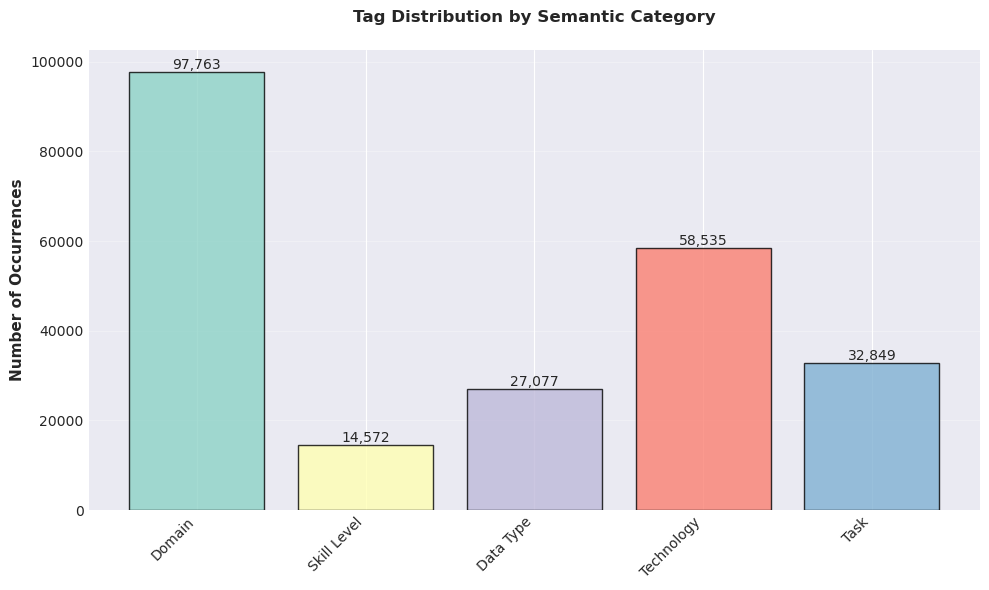

In [16]:
# Visualize category distribution
fig, ax = plt.subplots(figsize=(10, 6))

categories = list(category_counts.keys())
counts = list(category_counts.values())

bars = ax.bar(categories, counts, color=plt.cm.Set3(range(len(categories))), 
              edgecolor='black', alpha=0.8)
ax.set_ylabel('Number of Occurrences', fontsize=11, fontweight='bold')
ax.set_title('Tag Distribution by Semantic Category', fontsize=12, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Temporal Trends Analysis

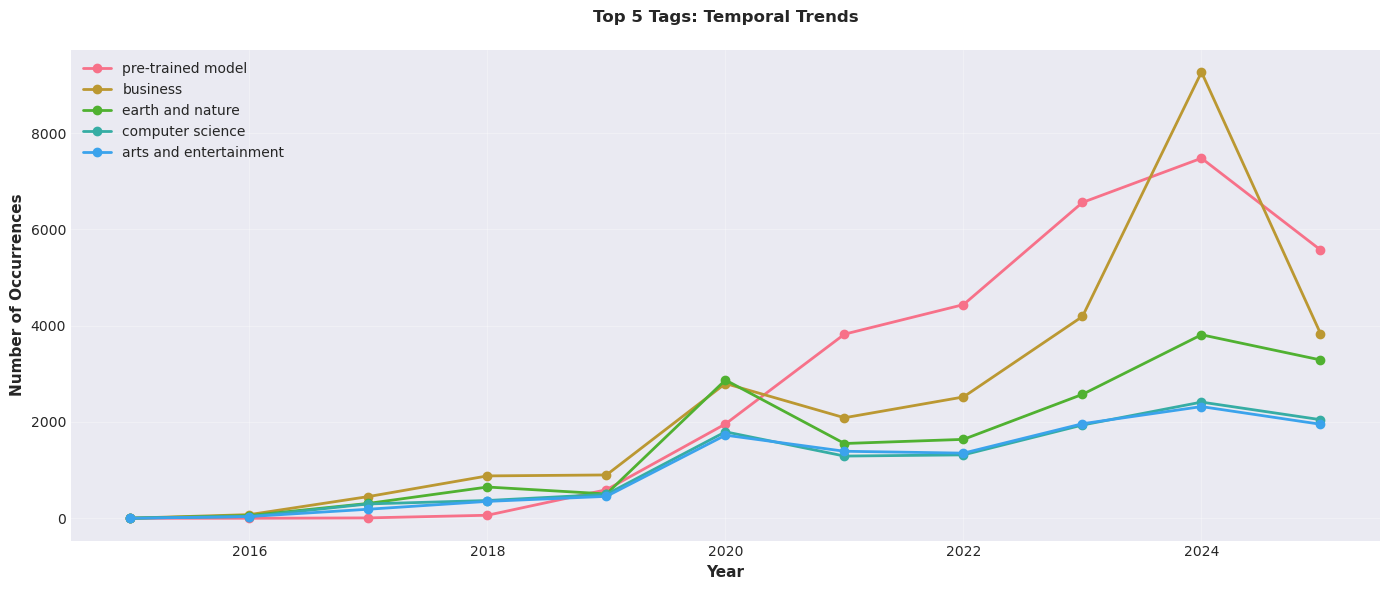

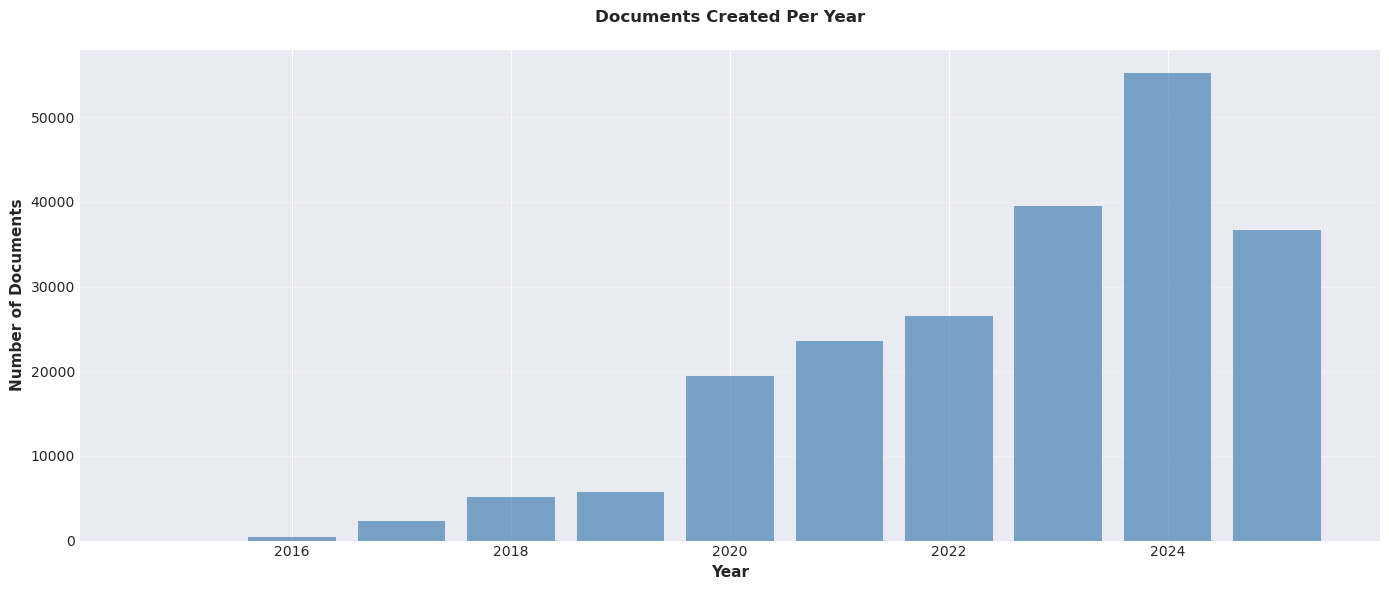

In [17]:
# Convert date columns if available
if 'CreationDate_dt' in df_with_tags.columns:
    df_with_tags['creation_year'] = pd.to_datetime(df_with_tags['CreationDate_dt']).dt.year
    
    # Analyze tag trends over time
    yearly_tag_counts = {}
    
    for _, row in df_with_tags.iterrows():
        year = row['creation_year']
        if pd.notna(year):
            if year not in yearly_tag_counts:
                yearly_tag_counts[year] = Counter()
            yearly_tag_counts[year].update(row['tags_list'])
    
    # Plot trends for top 5 tags
    top_5_tags = [tag for tag, _ in top_30_tags[:5]]
    
    plt.figure(figsize=(14, 6))
    
    for tag in top_5_tags:
        years = sorted(yearly_tag_counts.keys())
        counts = [yearly_tag_counts[year].get(tag, 0) for year in years]
        plt.plot(years, counts, marker='o', label=tag, linewidth=2)
    
    plt.xlabel('Year', fontsize=11, fontweight='bold')
    plt.ylabel('Number of Occurrences', fontsize=11, fontweight='bold')
    plt.title('Top 5 Tags: Temporal Trends', fontsize=12, fontweight='bold', pad=20)
    plt.legend(loc='best', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Documents per year
    docs_per_year = df_with_tags.groupby('creation_year').size()
    
    plt.figure(figsize=(14, 6))
    plt.bar(docs_per_year.index, docs_per_year.values, color='steelblue', alpha=0.7)
    plt.xlabel('Year', fontsize=11, fontweight='bold')
    plt.ylabel('Number of Documents', fontsize=11, fontweight='bold')
    plt.title('Documents Created Per Year', fontsize=12, fontweight='bold', pad=20)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("CreationDate_dt column not found - skipping temporal analysis")

## 8. Advanced Visualizations

In [18]:
# Word Cloud of tags
try:
    from wordcloud import WordCloud
    
    # Create word cloud
    wordcloud = WordCloud(width=1600, height=800, 
                          background_color='white',
                          colormap='viridis',
                          relative_scaling=0.5,
                          min_font_size=10).generate_from_frequencies(tag_counter)
    
    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Tag Word Cloud (Size = Frequency)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("WordCloud library not installed. Install with: pip install wordcloud")
    print("Skipping word cloud visualization.")

WordCloud library not installed. Install with: pip install wordcloud
Skipping word cloud visualization.


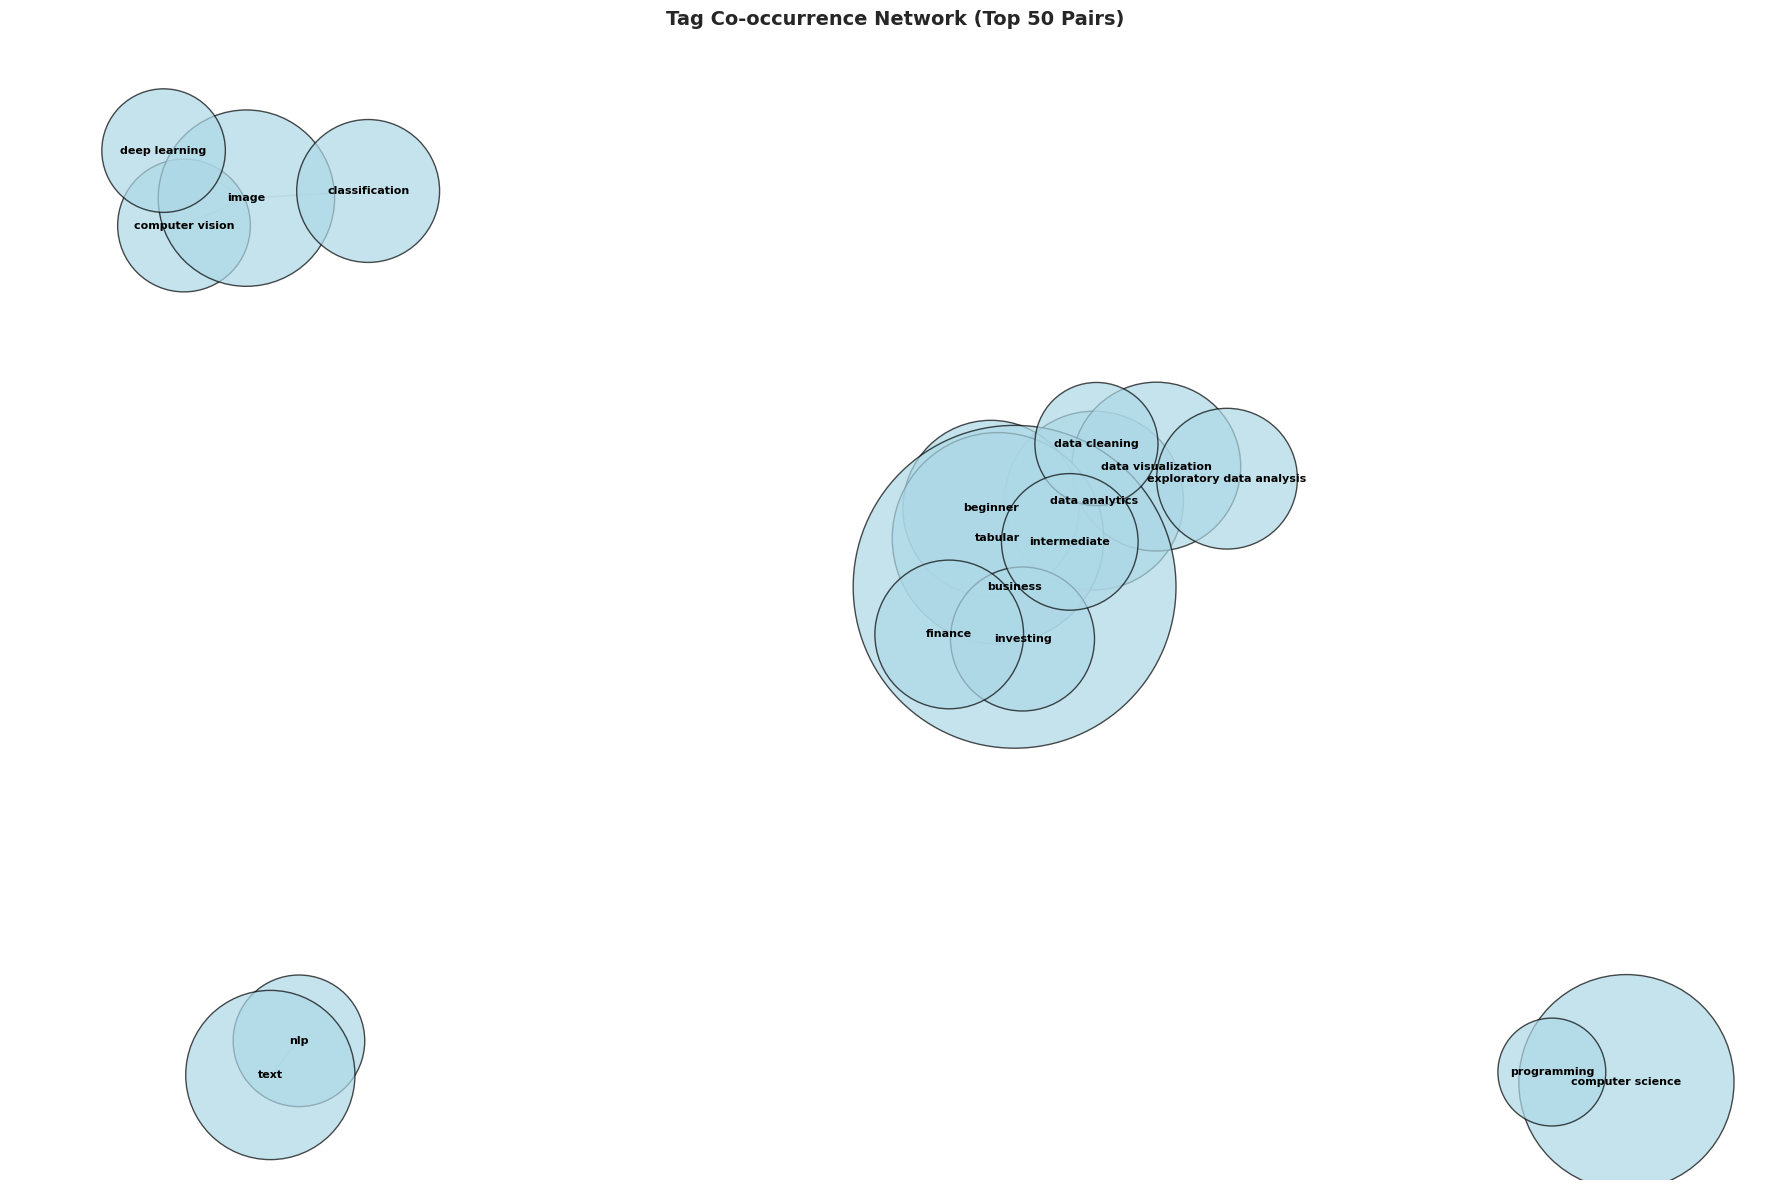


Network Statistics:
Nodes (unique tags): 18
Edges (co-occurrences): 20
Average degree: 2.22


In [19]:
# Network graph of tag co-occurrences
try:
    import networkx as nx
    
    # Create graph from top co-occurrences
    G = nx.Graph()
    
    # Add edges for top 50 co-occurrences
    for (tag1, tag2), count in top_cooccurrences[:50]:
        G.add_edge(tag1, tag2, weight=count)
    
    # Calculate node sizes based on tag frequency
    node_sizes = [tag_counter[node] * 2 for node in G.nodes()]
    
    plt.figure(figsize=(18, 12))
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Draw network
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                          node_color='lightblue', alpha=0.7, edgecolors='black')
    nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    
    plt.title('Tag Co-occurrence Network (Top 50 Pairs)', fontsize=14, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Network statistics
    print(f"\nNetwork Statistics:")
    print(f"Nodes (unique tags): {G.number_of_nodes()}")
    print(f"Edges (co-occurrences): {G.number_of_edges()}")
    print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
    
except ImportError:
    print("NetworkX library not installed. Install with: pip install networkx")
    print("Skipping network visualization.")

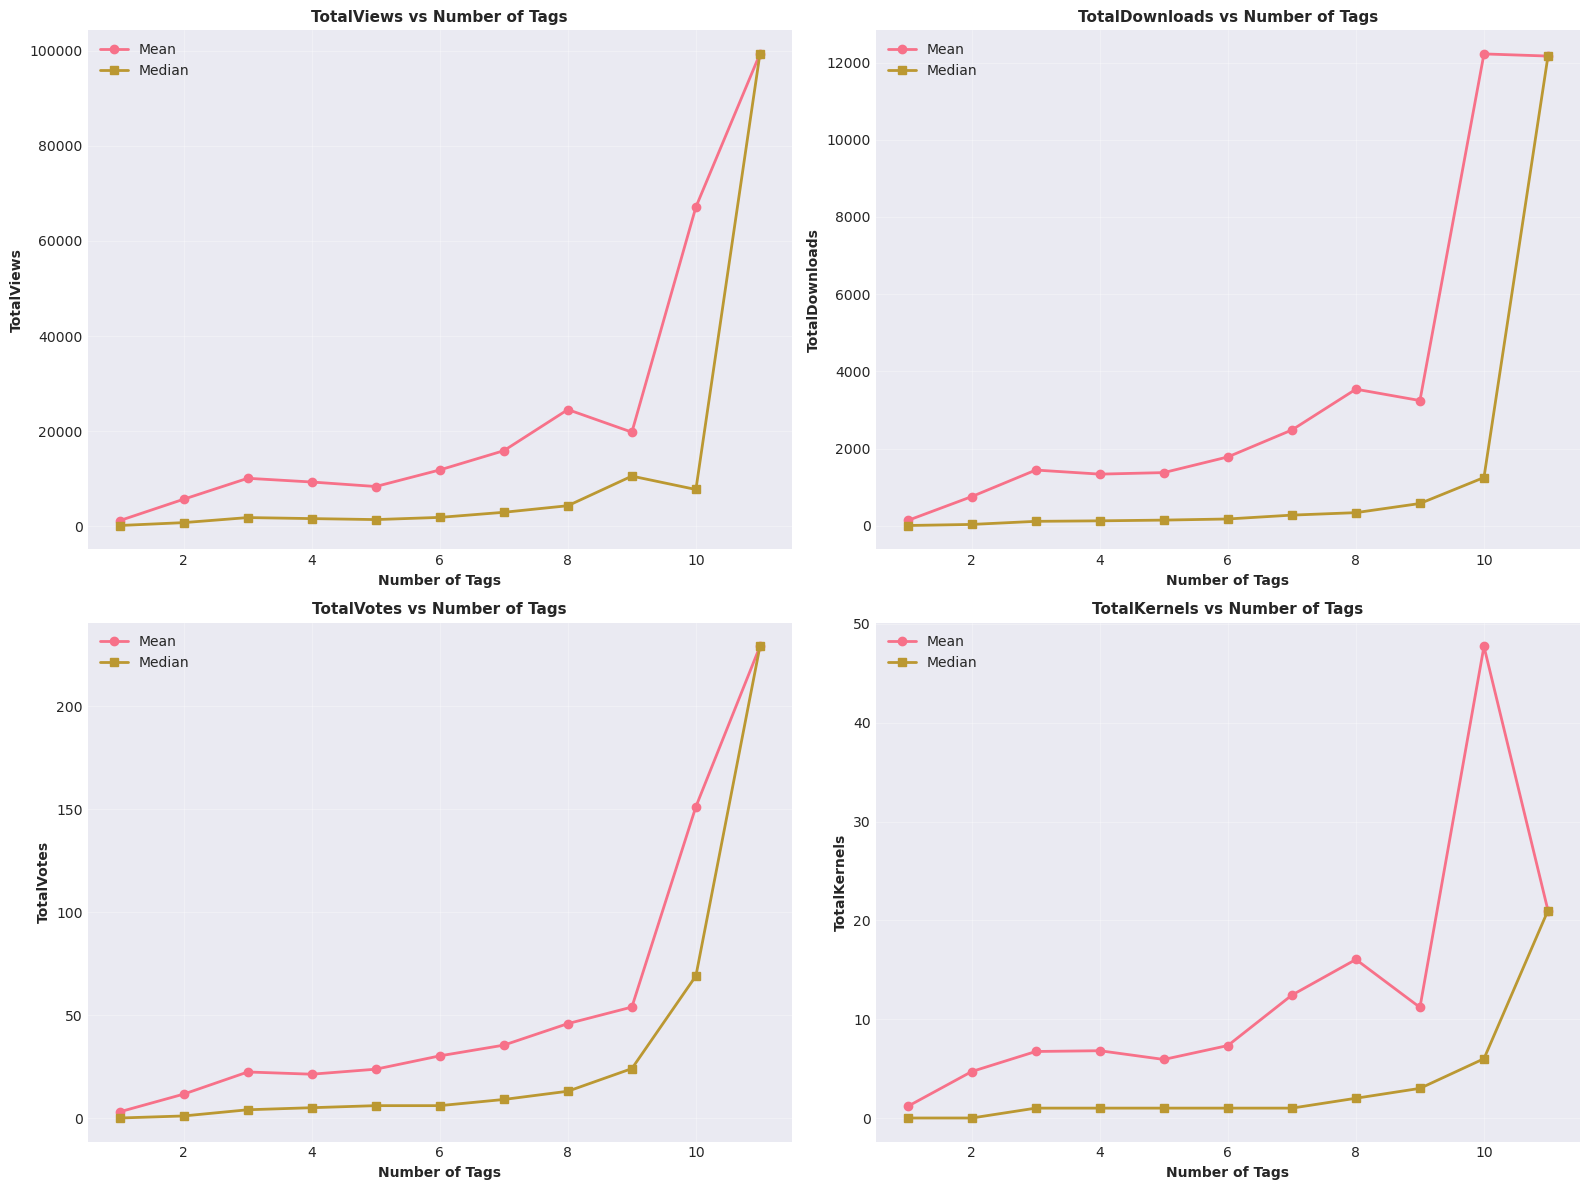

In [20]:
# Correlation: Number of tags vs engagement metrics
engagement_cols = ['TotalViews', 'TotalDownloads', 'TotalVotes', 'TotalKernels']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(engagement_cols):
    if col in df_with_tags.columns:
        # Group by number of tags
        grouped = df_with_tags.groupby('num_tags')[col].agg(['mean', 'median'])
        
        axes[i].plot(grouped.index, grouped['mean'], marker='o', label='Mean', linewidth=2)
        axes[i].plot(grouped.index, grouped['median'], marker='s', label='Median', linewidth=2)
        axes[i].set_xlabel('Number of Tags', fontsize=10, fontweight='bold')
        axes[i].set_ylabel(col, fontsize=10, fontweight='bold')
        axes[i].set_title(f'{col} vs Number of Tags', fontsize=11, fontweight='bold')
        axes[i].legend()
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Summary Report

In [21]:
print("="*80)
print("TAG ANALYSIS SUMMARY REPORT")
print("="*80)
print()
print("KEY FINDINGS:")
print("-" * 80)
print(f"1. Dataset Coverage:")
print(f"   - Total documents: {len(df):,}")
print(f"   - Documents with tags: {len(df_with_tags):,} ({len(df_with_tags)/len(df)*100:.1f}%)")
print()
print(f"2. Tag Diversity:")
print(f"   - Unique tags: {len(unique_tags):,}")
print(f"   - Average tags per document: {len(all_tags)/len(df_with_tags):.2f}")
print(f"   - Most common tag: '{top_30_tags[0][0]}' ({top_30_tags[0][1]:,} occurrences)")
print()
print(f"3. Tag Distribution:")
print(f"   - {len(rare_tags)} tags appear only once (rare/noisy tags)")
print(f"   - Top {tags_80} tags cover 80% of all tag occurrences")
print(f"   - {(tags_per_doc_dist.get(1, 0) / len(df_with_tags) * 100):.1f}% of documents have only 1 tag")
print()
print(f"4. Co-occurrence Patterns:")
print(f"   - Total unique tag pairs: {len(cooccurrence):,}")
print(f"   - Most common pair: '{top_cooccurrences[0][0][0]}' + '{top_cooccurrences[0][0][1]}' ({top_cooccurrences[0][1]:,} times)")
print()
print("5. Tag Categories:")
top_category = max(category_counts.items(), key=lambda x: x[1])
print(f"   - Most common category: {top_category[0]} ({top_category[1]:,} occurrences)")
print()
print("INSIGHTS & RECOMMENDATIONS:")
print("-" * 80)
print("• High tag diversity (597 unique tags) suggests rich metadata")
print("• Strong long-tail distribution indicates need for tag consolidation")
print("• Co-occurrence patterns reveal semantic clusters (e.g., data science, finance)")
print("• 58.9% of documents lack tags - opportunity for automated tagging")
print("• Consider hierarchical tagging system for better organization")
print("• Rare tags (67 appearing once) may benefit from tag suggestion features")
print("="*80)

TAG ANALYSIS SUMMARY REPORT

KEY FINDINGS:
--------------------------------------------------------------------------------
1. Dataset Coverage:
   - Total documents: 521,735
   - Documents with tags: 214,603 (41.1%)

2. Tag Diversity:
   - Unique tags: 597
   - Average tags per document: 2.08
   - Most common tag: 'pre-trained model' (30,498 occurrences)

3. Tag Distribution:
   - 67 tags appear only once (rare/noisy tags)
   - Top 86 tags cover 80% of all tag occurrences
   - 61.7% of documents have only 1 tag

4. Co-occurrence Patterns:
   - Total unique tag pairs: 31,711
   - Most common pair: 'data analytics' + 'data visualization' (3,403 times)

5. Tag Categories:
   - Most common category: Domain (97,763 occurrences)

INSIGHTS & RECOMMENDATIONS:
--------------------------------------------------------------------------------
• High tag diversity (597 unique tags) suggests rich metadata
• Strong long-tail distribution indicates need for tag consolidation
• Co-occurrence patterns 

## Appendix: Export Data for Further Analysis

In [22]:
# Export tag statistics to CSV
tag_stats_df = pd.DataFrame([
    {'tag': tag, 'frequency': count, 'percentage': count/len(df_with_tags)*100}
    for tag, count in tag_counter.most_common()
])

tag_stats_df.to_csv('tag_statistics.csv', index=False)
print("Tag statistics exported to 'tag_statistics.csv'")

# Export co-occurrence data
cooc_df = pd.DataFrame([
    {'tag1': tag1, 'tag2': tag2, 'count': count}
    for (tag1, tag2), count in sorted(cooccurrence.items(), key=lambda x: x[1], reverse=True)
])

cooc_df.to_csv('tag_cooccurrence.csv', index=False)
print("Tag co-occurrence data exported to 'tag_cooccurrence.csv'")

Tag statistics exported to 'tag_statistics.csv'
Tag co-occurrence data exported to 'tag_cooccurrence.csv'
